# MMI 1 X 2 / 2 x 2

## Librerías

In [2]:
import matplotlib.pyplot as plt
import numpy as np

import tidy3d as td
import gplugins.tidy3d as gt

nm = 1e-3
wavelength = np.linspace(1500, 1600) * nm
f = td.C_0 / wavelength


In [3]:
import importlib
import upvfab_design_tools

importlib.reload(upvfab_design_tools)
from upvfab_design_tools import MMI_EME, DC_EME


In [4]:
nitride_complex = td.material_library["Si3N4"]["Luke2015PMLStable"].eps_model(f)
nitride_index, nitride_k = td.Medium.eps_complex_to_nk(nitride_complex)
box_complex = td.material_library["SiO2"]["Horiba"].eps_model(f)
box_index, box_k = td.Medium.eps_complex_to_nk(box_complex)

## Diseño del MMI 1X2

In [5]:

# Simulation flow for MMI Couplers
# Define your geometrical parameters here
mmi_Width = 5.5 # Student. Body width

# m = MMI_EME(VERBOSE=True)  ## --> Para ver el indice efectivo de cada uno de los modos que se propagan 
m = MMI_EME() # Here you instantiate a MMI to be simulated with the Eigen-mode expansion (EME) algorithm.
m.MMI_width = mmi_Width
m.wg_width_dw = 0.5 # Ancho adicional de la guia para que sea del tamaño del taper
m.MMI_num_modes = 30 # Number of modes to be calculated. Here, the higher, the better since we are going to calculate
                    # the propagation based on the mode decomposition. 

# 1) Compute de MMI body modes - Only execute whenever a geometrical parameter is changed. Takes time to find the modes. 
m.find_all_modes()

# 2) Get the L_pi 
L_pi = m.get_L_pi()
print("L_pi = ", L_pi, " µm")

/home/au/pic-upv-TFM-Paula-Ortiz/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


L_pi =  48.81383142686555  µm


/home/au/pic-upv-TFM-Paula-Ortiz/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


Si tomamos un diseño 2 x 2 la longitud del MMI debe ser de $L_{pi}/2$ mientras que si lo tomamos como un MMI 1 x 2 la longitud será cercana a $\frac{3*L_{pi}}{4*2}$

In [13]:
print("La longitud para un MMI 2 x 2 sería de: ", np.round(L_pi/2,2), "um" )
print("La longitud para un MMI 1 x 2 sería de: ", np.round(3*L_pi/8,2), "um" )

print("La diferencia de longitud es de: ", np.round(L_pi/2-3*L_pi/8,2), "um" )

La longitud para un MMI 2 x 2 sería de:  24.41 um
La longitud para un MMI 1 x 2 sería de:  18.31 um
La diferencia de longitud es de:  6.1 um


La longitud del MMI 1 X 2 es parecida al del diseño de ommatidia 

## Propagación del MMI 2 X 2 

  0%|          | 0/6 [00:00<?, ?it/s]

  0%|          | 0/488 [00:00<?, ?it/s]

------- Pameters -------
MMI length 24.4069
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.5000
------------------------
Total power IN coupled 0.9804
Total OUT power: 0.9438
Excess loss [dB] =  0.1654
------------------------
Power over OUTs:  ['0.4689', '0.4749']
Ratio over OUTs ['0.4968', '0.5032']
Phase over OUTs ['-91.9864', '-177.1788']


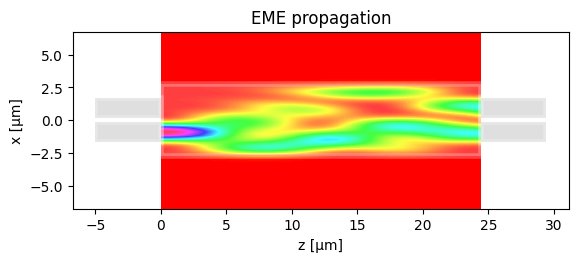

In [9]:
m.n_IN =  2 # STUDENT
m.n_OUT = 2 # STUDENT

dy = 0

# MMI I/O waveguide positions (check class slides for type of MMI)
m.IN_WVG_positions = mmi_Width*np.array([-1/6, 1/6]) + np.array([-dy, dy]) # STUDENT
m.OUT_WVG_positions = mmi_Width*np.array([-1/6,1/6]) + np.array([-dy, dy]) # STUDENT

m.L_MMI = L_pi/2
# MMI length (check class slides for type of MMI)
#m.dL_MMI = -0.15 # STUDENT

# Run propagation
power, power_total,power_in, phase=m.propagation()


  0%|          | 0/6 [00:00<?, ?it/s]

  0%|          | 0/366 [00:00<?, ?it/s]

------- Pameters -------
MMI length 18.3052
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.5000
------------------------
Total power IN coupled 0.9808
Total OUT power: 0.9666
Excess loss [dB] =  0.0632
------------------------
Power over OUTs:  ['0.4833', '0.4833']
Ratio over OUTs ['0.5000', '0.5000']
Phase over OUTs ['79.3582', '79.3575']


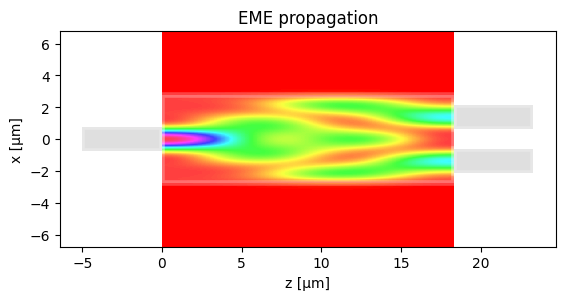

In [12]:
m.n_IN =  1 # STUDENT
m.n_OUT = 2 # STUDENT

dy = 0

# MMI I/O waveguide positions (check class slides for type of MMI)
m.IN_WVG_positions = mmi_Width*np.array([0]) # STUDENT
m.OUT_WVG_positions = mmi_Width*np.array([-1/4,1/4]) + np.array([-dy, dy]) # STUDENT

m.L_MMI = 3*L_pi/8
# MMI length (check class slides for type of MMI)
#m.dL_MMI = -0.15 # STUDENT

# Run propagation
power, power_total,power_in, phase=m.propagation()
